In [ ]:
# https://colab.research.google.com/drive/1WIk2bxglElfZewOHboPFNj8H44_VAyKE?usp=sharing#scrollTo=p3CAvlBZ58Fp

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install datasets
!pip3 install rouge-score==0.0.4
!pip3 install transformers
!pip3 install scipy==1.7.0
!pip3 install sentence-transformers==2.0.0
!pip3 install sentencepiece==0.1.96
!pip3 install tokenizers
!pip3 install torch==1.9.0
!pip3 install tqdm==4.62.3
!pip install -Uqq ipdb

     |████████████████████████████████| 325 kB 5.1 MB/s 
     |████████████████████████████████| 1.1 MB 41.7 MB/s 
     |████████████████████████████████| 77 kB 6.2 MB/s 
     |████████████████████████████████| 136 kB 46.6 MB/s 
     |████████████████████████████████| 212 kB 32.8 MB/s 
     |████████████████████████████████| 127 kB 51.2 MB/s 
     |████████████████████████████████| 144 kB 50.2 MB/s 
     |████████████████████████████████| 94 kB 3.1 MB/s 
     |████████████████████████████████| 271 kB 43.4 MB/s 
  Attempting uninstall: urllib3
    Found existing installation: urllib3 1.24.3
    Uninstalling urllib3-1.24.3:
      Successfully uninstalled urllib3-1.24.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datascience 0.10.6 requires folium==0.2.1, but you have folium 0.8.3 which is incompatible.
     |████████████████████████████████| 4.0 MB 5.1 MB/s 


In [ ]:
import torch
import matplotlib.pyplot as plt
import os
import pandas as pd
import numpy as np
from PIL import Image
from sklearn.utils import shuffle
import gc
import tqdm
import sys
from transformers import Seq2SeqTrainingArguments

sys.path.append('/content/drive/MyDrive/Joke Generation Project')
from Custom_Losses import CustomTrainer
from Data_Loaders import load_and_tokenize_data
from Model_Initialization import load_roberta_encoder_decoder

In [ ]:
#Specify Training Parameters:
batch_size = 64

training_args = Seq2SeqTrainingArguments(
    predict_with_generate=True,
    evaluation_strategy="steps",
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    fp16=True, 
    output_dir="/WEIGHTEDROBERTA2ROBERTA_FINAL",
    do_eval=False,
    # save_steps=10,
    # eval_steps=4,
    logging_steps=1000,
    save_steps=4855*2.5,
    eval_steps=4,
    num_train_epochs=5.0,
    # warmup_steps=2000,
    # save_total_limit=3,
    remove_unused_columns = False,
)

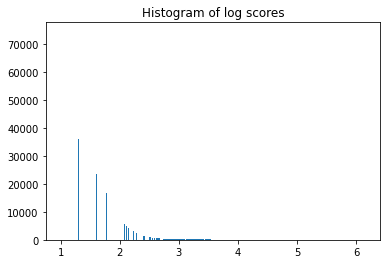

  0%|          | 0/4855 [00:00<?, ?ba/s]

  0%|          | 0/32 [00:00<?, ?ba/s]

1
2
0


In [ ]:
# Loading, applying log transformation to scores and tokenizing text:
train_data,eval_data,tokenizer = load_and_tokenize_data(directory ="/Clean_Joke_Data.csv",
              num_words_buildup = 50, num_words_punch = 20, remove_duplicate_punchlines = True,
              discrete_scores = False, batch_size = batch_size)

#Printing out special tokens and their ids:
print(tokenizer.pad_token_id)
print(tokenizer.eos_token_id)
print(tokenizer.bos_token_id)

In [ ]:
roberta_model = load_roberta_encoder_decoder(directory ="/WEIGHTEDROBERTA2ROBERTA_FINAL/checkpoint-24275")

The following encoder weights were not tied to the decoder ['roberta/pooler']
The following encoder weights were not tied to the decoder ['roberta/pooler']


In [ ]:
trainer = CustomTrainer(
    model=roberta_model,
    tokenizer=tokenizer,
    args=training_args,
    train_dataset=train_data,
    eval_dataset=eval_data
)
#print(trainer._signature_columns)
trainer.train()

Using amp half precision backend
/usr/local/lib/python3.7/dist-packages/transformers/optimization.py:309: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  FutureWarning,
***** Running training *****
  Num examples = 310694
  Num Epochs = 5
  Instantaneous batch size per device = 64
  Total train batch size (w. parallel, distributed & accumulation) = 64
  Gradient Accumulation steps = 1
  Total optimization steps = 24275
/usr/local/lib/python3.7/dist-packages/transformers/models/encoder_decoder/modeling_encoder_decoder.py:530: FutureWarning: Version v4.12.0 introduces a better way to train encoder-decoder models by computing the loss inside the encoder-decoder framework rather than in the decoder itself. You may observe training discrepancies if fine-tuning a model trained with versions anterior to 4.12.0. The decoder_

Step,Training Loss,Validation Loss


KeyboardInterrupt: ignored